**Clusters**

La predicción de temperatura media se realizará a la mínima escala posible (estación de AEMET).

Es inviable realizar un modelo predictivo para cada una de las 924 estaciones de la AEMET.

El desarrollo de un número viable de modelos requiere agrupar las estaciones.

Los patrones climáticos regionales son características climáticas comunes entre estaciones.

Las características climáticas comunes son:

- Altitud ("altitud")
- Diferencia entre temperatura media en verano y temperatura media en invierno ("tmed_range")
- Logaritmo de la precipitación acumulada ("log_prec_mean")
- Humedad relativa media promedio ("hrMedia_mean")

Agrupamos las estaciones según patrones climáticos regionales mediante Clustering Jerárquico Aglomerativo.

El número de clusteres es evaluados mediante Silhoutte score y Davis Bouldin Score:

- Silhoutte score menor a 0.3 refleja la cohesión de las estaciones dentro de un cluster (resultado entre 0.3 a 0.4 indica cohesión suficiente para modelar).
- Davis Boulding Score menor a 1.5 evalua la separación entre los clústeres (resultado menor a 1 indica clusteres suficientemente distintos para modelar).

Desarrollamos un modelo predictivo para cada uno de los grupos (clusters) de estaciones.


**Extra**: los clusters son utilizados también en la limpieza para la imputación de NaN de los datos extraídos de la AEMET

In [12]:
import pandas as pd
import geopandas as gpd
import folium
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.spatial.distance import euclidean
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load data
temperaturas_path = "data/temperaturas_limpias_10_años_final.pkl"
estaciones_path = "data/estaciones_corregidas.csv"
geojson_path = "data/spain-provinces.geojson"

# Verify file existence
for path in [temperaturas_path, estaciones_path, geojson_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

# Read data
df = pd.read_pickle(temperaturas_path)
stations_df = pd.read_csv(estaciones_path)

# Check for duplicates in stations_df
print("Duplicate indicativo in stations_df:", stations_df['indicativo'].duplicated().sum())

# Merge coordinates, keeping unique indicativo
stations_subset = stations_df[['indicativo', 'latitud_dd', 'longitud_dd']].drop_duplicates('indicativo')
df = df.merge(stations_subset, on='indicativo', how='left')

# Check for duplicates in df
print("Duplicate indicativo in df:", df['indicativo'].duplicated().sum())

# Define seasons
df['season'] = df['fecha'].dt.month.map({
    1: 'winter', 2: 'winter', 12: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'fall', 10: 'fall', 11: 'fall'
})

# Aggregate station features
station_features = df.groupby('indicativo').agg({
    'altitud': 'first',
    'tmed': [
        'mean',
        lambda x: x[df['season'] == 'winter'].mean(),
        lambda x: x[df['season'] == 'spring'].mean(),
        lambda x: x[df['season'] == 'summer'].mean(),
        lambda x: x[df['season'] == 'fall'].mean()
    ],
    'prec': 'mean',
    'hrMedia': 'mean',
    'velmedia': 'mean',
    'longitud_dd': 'first',
    'latitud_dd': 'first',
}).reset_index()

# Flatten column names
station_features.columns = [
    'indicativo', 'altitud', 'tmed_mean', 'tmed_winter', 'tmed_spring', 'tmed_summer', 'tmed_fall',
    'prec_mean', 'hrMedia_mean', 'velmedia_mean', 'longitud_dd', 'latitud_dd'
]

# Check for duplicates in station_features
print("Duplicate indicativo in station_features:", station_features['indicativo'].duplicated().sum())
print("Number of stations:", len(station_features))

# Handle missing seasonal values
station_features[['tmed_winter', 'tmed_spring', 'tmed_summer', 'tmed_fall', 'hrMedia_mean', 'velmedia_mean']] = station_features[
    ['tmed_winter', 'tmed_spring', 'tmed_summer', 'tmed_fall', 'hrMedia_mean', 'velmedia_mean']
].fillna(station_features['tmed_mean'])

# Feature engineering
station_features['tmed_range'] = station_features['tmed_summer'] - station_features['tmed_winter']
station_features['prec_mean_log'] = np.log1p(station_features['prec_mean'])
station_features['velmedia_mean_log'] = np.log1p(station_features['velmedia_mean'])

Duplicate indicativo in stations_df: 0
Duplicate indicativo in df: 2021974
Duplicate indicativo in station_features: 0
Number of stations: 924


Imputando 4 valores nulos en tmed_range con la mediana: 14.44


C:\Users\User\AppData\Local\Temp\ipykernel_22540\1821594172.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  station_features['tmed_range'].fillna(tmed_range_median, inplace=True)


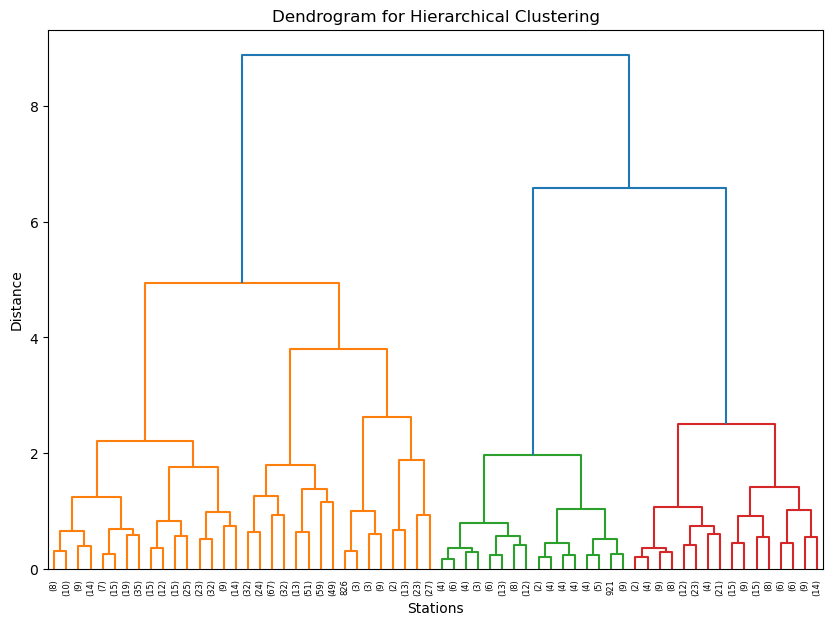

n_clusters=6: 6 clusters
cluster
0    165
1    262
2     89
3     65
4    327
5     16
Name: count, dtype: int64
Silhouette Score: 0.331
Davies-Bouldin Index: 0.955
n_clusters=8: 8 clusters
cluster
0     89
1     65
2    145
3     82
4    327
5     16
6     83
7    117
Name: count, dtype: int64
Silhouette Score: 0.253
Davies-Bouldin Index: 1.188
n_clusters=10: 10 clusters
cluster
0    327
1     82
2    145
3    117
4     33
5     16
6     83
7     50
8     56
9     15
Name: count, dtype: int64
Silhouette Score: 0.249
Davies-Bouldin Index: 1.125
n_clusters=12: 12 clusters
cluster
0      82
1     155
2     172
3     117
4      33
5      16
6      83
7      50
8      56
9      15
10     78
11     67
Name: count, dtype: int64
Silhouette Score: 0.226
Davies-Bouldin Index: 1.190


In [26]:
# Impute missing tmed_range with median
if station_features['tmed_range'].isnull().sum() > 0:
    tmed_range_median = station_features['tmed_range'].median()
    print(f"Imputando {station_features['tmed_range'].isnull().sum()} valores nulos en tmed_range con la mediana: {tmed_range_median:.2f}")
    station_features['tmed_range'].fillna(tmed_range_median, inplace=True)

# Prepare features
X = station_features[['altitud', 'tmed_range', 'prec_mean_log', 'hrMedia_mean']].values #'latitud_dd', 'longitud_dd', 'velmedia_mean_log'
scaler = MinMaxScaler()  # StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dendrogram to guide n_clusters
linked = linkage(X_scaled, method='ward', metric='euclidean')
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Stations')
plt.ylabel('Distance')
plt.show()

# Test Agglomerative Clustering with multiple n_clusters
for n_clusters in [6, 8, 10, 12]:
    clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward', metric='euclidean')
    labels = clustering.fit_predict(X_scaled)
    print(f"n_clusters={n_clusters}: {len(set(labels))} clusters")
    print(station_features.assign(cluster=labels)['cluster'].value_counts().sort_index())
    print(f"Silhouette Score: {silhouette_score(X_scaled, labels):.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, labels):.3f}")

In [28]:
# Run Agglomerative Clustering with n_clusters=6
clustering = AgglomerativeClustering(n_clusters=6, linkage='ward', metric='euclidean')
labels = clustering.fit_predict(X_scaled)
station_features['cluster'] = labels

# Verify clustering
print(f"Number of clusters: {len(set(labels))}")
print("Stations per cluster:\n", station_features['cluster'].value_counts().sort_index())
print(f"Silhouette Score: {silhouette_score(X_scaled, labels):.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, labels):.3f}")

Number of clusters: 6
Stations per cluster:
 cluster
0    165
1    262
2     89
3     65
4    327
5     16
Name: count, dtype: int64
Silhouette Score: 0.331
Davies-Bouldin Index: 0.955


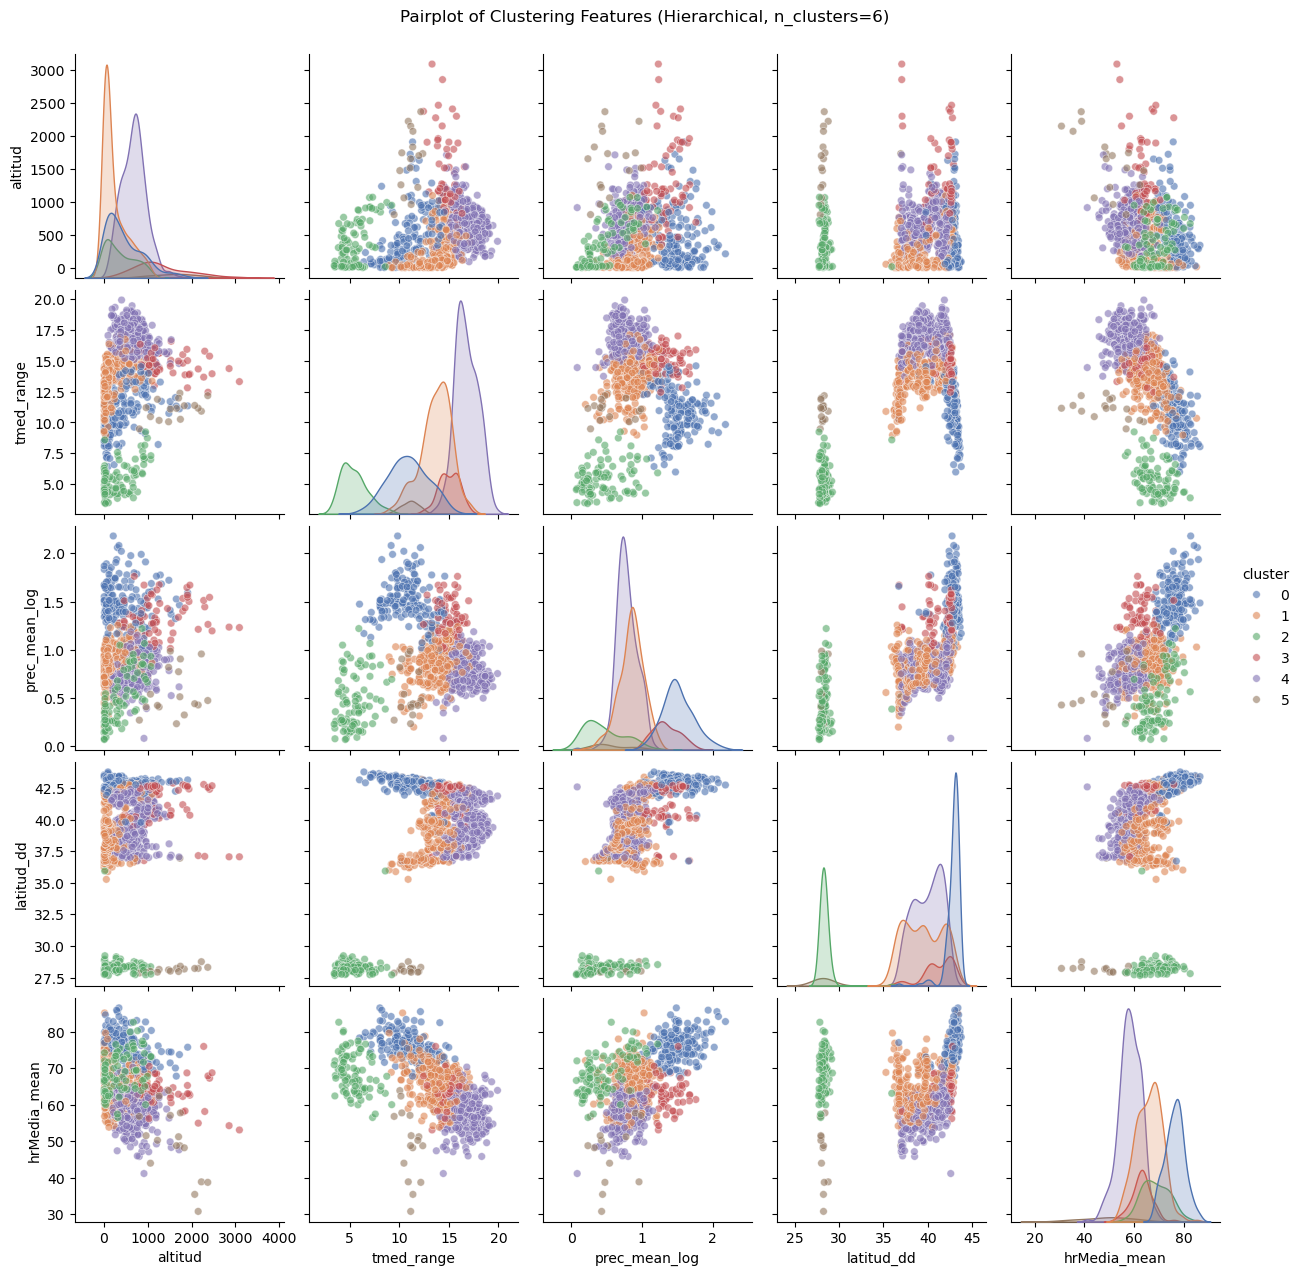

Cluster feature means:
              altitud  tmed_range  prec_mean_log  hrMedia_mean  latitud_dd  \
cluster                                                                     
0         455.563636   10.880673       1.508051     76.346511   42.853357   
1         238.080153   13.657146       0.843046     65.887310   39.486929   
2         359.393258    5.440962       0.461852     68.661811   28.347076   
3        1301.323077   14.995646       1.338997     62.990292   41.204355   
4         676.422018   16.753094       0.779527     58.192951   39.969276   
5        1610.625000   11.064936       0.555897     49.021354   28.699028   

         longitud_dd  
cluster               
0          -4.947857  
1          -1.567186  
2         -16.081870  
3          -2.206795  
4          -3.158991  
5         -15.516076  
Output DataFrame head:
   indicativo  altitud       tmed  hrMedia_mean  latitud_dd  longitud_dd  \
0      0002I       32  17.110377     62.209930   40.958056     0.871389   
1

In [30]:
# Visualize with pairplot
sns.pairplot(
    station_features,
    vars=['altitud', 'tmed_range', 'prec_mean_log', 'latitud_dd', 'hrMedia_mean'], #'hrMedia_mean'
    hue='cluster',
    palette='deep',
    plot_kws={'s': 30, 'alpha': 0.6},
    diag_kind='kde'
)
plt.suptitle('Pairplot of Clustering Features (Hierarchical, n_clusters=6)', y=1.02)
plt.show()

# Cluster summary
print("Cluster feature means:\n", station_features.groupby('cluster')[['altitud', 'tmed_range', 'prec_mean_log', 'hrMedia_mean', 'latitud_dd', 'longitud_dd']].mean())

# Create output DataFrame
output_df = station_features[['indicativo', 'altitud', 'tmed_mean', 'hrMedia_mean', 'latitud_dd', 'longitud_dd', 'cluster']].copy()
output_df = output_df.rename(columns={'tmed_mean': 'tmed'})
print("Output DataFrame head:\n", output_df.head())

In [32]:
# Convert to GeoDataFrame
gdf_stations = gpd.GeoDataFrame(
    station_features,
    geometry=gpd.points_from_xy(station_features['longitud_dd'], station_features['latitud_dd']),
    crs="EPSG:4326"
)

# Load Spain provinces GeoJSON
spain_provinces = gpd.read_file(geojson_path)
if spain_provinces.crs != 'EPSG:4326':
    spain_provinces = spain_provinces.to_crs('EPSG:4326')
print(f"Provinces CRS: {spain_provinces.crs}")
spain_provinces = spain_provinces[['geometry', 'name']]

# Batch spatial join for provinces
gdf_stations = gdf_stations.sjoin(spain_provinces, how='left', predicate='within')
gdf_stations['name'] = gdf_stations['name'].fillna('Unknown')

Provinces CRS: EPSG:4326


In [34]:
# Inicializar mapa folium
m = folium.Map(location=[39.0, -4.0], zoom_start=5, tiles='CartoDB positron')

# Agregar límites de provincias
folium.GeoJson(
    spain_provinces,
    style_function=lambda x: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.1
    },
    tooltip=folium.GeoJsonTooltip(fields=['name'], aliases=['Province'])
).add_to(m)

# Paleta de colores para clusteres
cluster_colors = {
    0: 'blue', 1: 'red', 2: 'green', 3: 'purple',
    4: 'orange', 5: 'cyan', 6: 'pink', 7: 'yellow',
    8: 'brown', 9: 'gray', 10: 'lime'
}

# Agregar puntos de estanciones (no MarkerCluster)
for idx, row in gdf_stations.iterrows():
    folium.CircleMarker(
        location=[row['latitud_dd'], row['longitud_dd']],
        radius=5,
        color=cluster_colors.get(row['cluster'], 'black'),
        fill=True,
        fill_color=cluster_colors.get(row['cluster'], 'black'),
        fill_opacity=0.7,
        popup=folium.Popup(
            f"Station: {row['indicativo']}<br>Province: {row['name']}<br>Cluster: {row['cluster']}<br>"
            f"Altitude: {row['altitud']} m<br>Mean Temp: {row['tmed_mean']:.1f} °C<br>"
            f"Temp Range: {row['tmed_range']:.1f} °C<br>Log Precip: {row['prec_mean_log']:.2f}",
            max_width=200
        )
    ).add_to(m)

# Agregar leyenda
legend_html = """
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; padding: 10px; background-color: white; border: 2px solid grey; border-radius: 5px;">
    <h4>Cluster Legend</h4>
    """ + "".join([f'<p><span style="color:{color};font-size:20px;">●</span> Cluster {i}</p>' for i, color in cluster_colors.items() if i in station_features['cluster'].values]) + """
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Mapa
m

In [ ]:
#Join columna cluster a DataFrame limpio para modelar

df_clusters = df.merge(station_features, on="indicativo", how="left")

df_limpio_cluster = df[[
        "id_descarga", "fecha", "indicativo", "nombre", "provincia", "altitud",
        "tmin", "tmax", "tmed", "prec", "velmedia", "racha", "hrMedia", "timestamp_extraccion", "cluster"         
    ]]

In [ ]:
import os
import pandas as pd

cache_path = "c:/Repos/Augusto/data/inventario_estaciones.json"
if os.path.exists(cache_path):
    print(f"Cache file found at {cache_path}")
    try:
        inventario_estaciones = pd.read_json(cache_path)
        print(f"Cache loaded successfully. Contains {len(df)} stations.")
        print(df.head())
    except Exception as e:
        print(f"Error reading cache file: {e}")
else:
    print(f"Cache file not found at {cache_path}")


# Create output DataFrame
output_df = station_features[['indicativo', 'altitud', 'tmed_mean', 'hrMedia_mean', 'latitud_dd', 'longitud_dd', 'cluster']].copy()
output_df = output_df.rename(columns={'tmed_mean': 'tmed'})

#Agregado período de actividad
active_periods = df.groupby('indicativo')['fecha'].agg(['min', 'max']).reset_index()
active_periods.columns = ['indicativo', 'start_date', 'end_date']
output_df_II = output_df.merge(active_periods, on='indicativo', how='left')

#Agregado nombre_indicativo
inventario_estaciones = inventario_estaciones.rename(columns={'nombre': 'nombre_indicativo'})
nombre_indicativo = inventario_estaciones[['indicativo', 'nombre_indicativo']]
output_df_III = output_df_II.merge(nombre_indicativo, on='indicativo', how='left')
output_df_IV = output_df_III[['indicativo', 'nombre_indicativo', 'start_date', 'end_date', 'latitud_dd', 'longitud_dd',' cluster']] 

In [43]:
#Guardar

m.save(r'C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\spain_stations_map_jerarquico_revision.html')

station_features.to_csv(
    r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\station_features.csv",
    index=False
) #Para desarrollar el mapa en streamlit con las caracteristicas climáticas de cada estación

output_df_IV.to_csv(
    r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Final\estaciones.csv",
    index=False
) #Para la limpieza en el ETL

df_limpio_cluster.to_pickle(r"C:\Users\User\OneDrive - Universidade de Santiago de Compostela\Documentos\Data Science\Data Science & IA Bootcamp 2024\PFB\Sprint_II\notebooks\Temperaturas_limpias_con_firmas\temperaturas_limpias_10_años_clusters_revision.pkl")